# ASH_COATED_OSMIUM EMA Mean-Reversion Taker Simulation

This notebook simulates a pure market-taking strategy for `ASH_COATED_OSMIUM` based on the EMA mean-reversion signal.

Assumptions:
- quotes come from the three round-1 price files,
- the strategy is always a taker: buys cross the best ask and sells cross the best bid,
- entries happen when the EMA signal is extreme enough,
- exits happen when the signal normalizes or flips,
- positions are flattened at the end of each day.


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PRICE_FILES = [
    'prices_round_1_day_-2.csv',
    'prices_round_1_day_-1.csv',
    'prices_round_1_day_0.csv',
]

EMA_SPAN = 200
# Use a much stricter entry bar so the taker only trades on extreme dislocations.
ENTRY_THRESHOLD = 10.0
EXIT_THRESHOLD = 2.0
POSITION_LIMIT = 20
TRADE_SIZE = 5


In [10]:
def load_prices(file_names: list[str]) -> pd.DataFrame:
    frames = []
    for file_name in file_names:
        day = int(file_name.split('_day_')[1].split('.csv')[0])
        frame = pd.read_csv(Path(file_name), sep=';')
        frame['day'] = day
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


prices = load_prices(PRICE_FILES)
ash = prices.loc[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash = ash.sort_values(['day', 'timestamp']).reset_index(drop=True)

ash.loc[ash['mid_price'] == 0, 'mid_price'] = np.nan
ash['mid_price'] = ash.groupby('day')['mid_price'].transform(lambda s: s.ffill().bfill())
ash['bid'] = ash.groupby('day')['bid_price_1'].transform(lambda s: s.ffill().bfill())
ash['ask'] = ash.groupby('day')['ask_price_1'].transform(lambda s: s.ffill().bfill())
ash['spread'] = ash['ask'] - ash['bid']
ash['ema'] = ash['mid_price'].ewm(span=EMA_SPAN, adjust=False).mean()
ash['signal'] = ash['ema'] - ash['mid_price']
ash['global_step'] = np.arange(len(ash))

ash.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,bid,ask,spread,ema,signal,global_step
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,010.000",25.000,NaN,NaN,NaN,NaN,"10,010.000",0.000,"9,992.000","10,010.000",18.000,"10,010.000",0.000,0
1,-2,100,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,011.000",20.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,"10,009.900",9.900,1
2,-2,200,ASH_COATED_OSMIUM,"9,992.000",15.000,"9,989.000",30.000,NaN,NaN,"10,008.000",15.000,"10,010.000",30.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,"10,009.802",9.802,2
3,-2,300,ASH_COATED_OSMIUM,"9,992.000",13.000,"9,989.000",26.000,NaN,NaN,"10,008.000",13.000,"10,010.000",26.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,"10,009.704",9.704,3
4,-2,400,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,010.000",20.000,NaN,NaN,"10,000.000",0.000,"9,992.000","10,008.000",16.000,"10,009.608",9.608,4


In [ ]:
def simulate_taker_strategy(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    cash = 0.0
    position = 0
    trades = []
    rows = []

    current_day = None

    for row in df.itertuples(index=False):
        day = row.day
        timestamp = row.timestamp
        bid = float(row.bid)
        ask = float(row.ask)
        mid = float(row.mid_price)
        ema = float(row.ema)
        signal = float(row.signal)

        if current_day is None:
            current_day = day

        if day != current_day and position != 0:
            if position > 0:
                fill_qty = position
                fill_price = prev_bid
                cash += fill_qty * fill_price
                trades.append(
                    {
                        'day': current_day,
                        'timestamp': prev_timestamp,
                        'side': 'SELL',
                        'qty': fill_qty,
                        'price': fill_price,
                        'reason': 'day_end_flatten',
                    }
                )
            else:
                fill_qty = -position
                fill_price = prev_ask
                cash -= fill_qty * fill_price
                trades.append(
                    {
                        'day': current_day,
                        'timestamp': prev_timestamp,
                        'side': 'BUY',
                        'qty': fill_qty,
                        'price': fill_price,
                        'reason': 'day_end_flatten',
                    }
                )
            position = 0
            current_day = day

        trade_reason = None
        trade_side = None
        trade_qty = 0
        trade_price = np.nan

        if signal > ENTRY_THRESHOLD and position < POSITION_LIMIT:
            trade_qty = min(TRADE_SIZE, POSITION_LIMIT - position)
            if trade_qty > 0:
                trade_side = 'BUY'
                trade_price = ask
                trade_reason = 'enter_long'
                cash -= trade_qty * trade_price
                position += trade_qty
        elif signal < -ENTRY_THRESHOLD and position > -POSITION_LIMIT:
            trade_qty = min(TRADE_SIZE, POSITION_LIMIT + position)
            if trade_qty > 0:
                trade_side = 'SELL'
                trade_price = bid
                trade_reason = 'enter_short'
                cash += trade_qty * trade_price
                position -= trade_qty
        elif position > 0 and signal < EXIT_THRESHOLD:
            trade_qty = min(TRADE_SIZE, position)
            if trade_qty > 0:
                trade_side = 'SELL'
                trade_price = bid
                trade_reason = 'exit_long'
                cash += trade_qty * trade_price
                position -= trade_qty
        elif position < 0 and signal > -EXIT_THRESHOLD:
            trade_qty = min(TRADE_SIZE, -position)
            if trade_qty > 0:
                trade_side = 'BUY'
                trade_price = ask
                trade_reason = 'exit_short'
                cash -= trade_qty * trade_price
                position += trade_qty

        if trade_qty > 0:
            trades.append(
                {
                    'day': day,
                    'timestamp': timestamp,
                    'side': trade_side,
                    'qty': trade_qty,
                    'price': trade_price,
                    'reason': trade_reason,
                }
            )

        mark_to_market = cash + position * mid
        rows.append(
            {
                'day': day,
                'timestamp': timestamp,
                'mid_price': mid,
                'bid': bid,
                'ask': ask,
                'ema': ema,
                'signal': signal,
                'position': position,
                'cash': cash,
                'mtm_pnl': mark_to_market,
            }
        )

        prev_bid = bid
        prev_ask = ask
        prev_timestamp = timestamp
        current_day = day

    if position != 0:
        if position > 0:ASH_COATED_OSMIUM is rumored to be a bit more volatile, although one may speculate that its apparent unpredictability may follow a hidden pattern. 
            fill_qty = position
            fill_price = prev_bid
            cash += fill_qty * fill_price
            trades.append(
                {
                    'day': current_day,
                    'timestamp': prev_timestamp,
                    'side': 'SELL',
                    'qty': fill_qty,
                    'price': fill_price,ASH_COATED_OSMIUM is rumored to be a bit more volatile, although one may speculate that its apparent unpredictability may follow a hidden pattern. 
                    'reason': 'final_flatten',
                }
            )
        else:
            fill_qty = -position
            fill_price = prev_ask
            cash -= fill_qty * fill_price
            trades.append(
                {
                    'day': current_day,
                    'timestamp': prev_timestamp,
                    'side': 'BUY',
                    'qty': fill_qty,
                    'price': fill_price,
                    'reason': 'final_flatten',
                }
            )
        rows[-1]['position'] = 0
        rows[-1]['cash'] = cash
        rows[-1]['mtm_pnl'] = cash

    history = pd.DataFrame(rows)
    trades_df = pd.DataFrame(trades)
    return history, trades_df


history, trades = simulate_taker_strategy(ash)
history.head(), trades.head()


(   day  timestamp  mid_price       bid        ask        ema  signal  \
 0   -2          0 10,010.000 9,992.000 10,010.000 10,010.000   0.000   
 1   -2        100 10,000.000 9,992.000 10,008.000 10,009.900   9.900   
 2   -2        200 10,000.000 9,992.000 10,008.000 10,009.802   9.802   
 3   -2        300 10,000.000 9,992.000 10,008.000 10,009.704   9.704   
 4   -2        400 10,000.000 9,992.000 10,008.000 10,009.608   9.608   
 
    position  cash  mtm_pnl  
 0         0 0.000    0.000  
 1         0 0.000    0.000  
 2         0 0.000    0.000  
 3         0 0.000    0.000  
 4         0 0.000    0.000  ,
    day  timestamp  side  qty      price      reason
 0   -2        900   BUY    5  9,998.000  enter_long
 1   -2       1200  SELL    5  9,993.000   exit_long
 2   -2       1600   BUY    5 10,010.000  enter_long
 3   -2       4300  SELL    5  9,997.000   exit_long
 4   -2       5600   BUY    5 10,012.000  enter_long)

In [ ]:
summary = pd.DataFrame(
    {
        'metric': [
            'final pnl',
            'max pnl',
            'min pnl',
            'total trades',
            'buy trades',
            'sell trades',
            'avg spread',
            'max absolute position',
        ],
        'value': [
            history['mtm_pnl'].iloc[-1],
            history['mtm_pnl'].max(),
            history['mtm_pnl'].min(),
            len(trades),
            int((trades['side'] == 'BUY').sum()),
            int((trades['side'] == 'SELL').sum()),
            ash['spread'].mean(),
            history['position'].abs().max(),
        ],
    }
)

summaryASH_COATED_OSMIUM is rumored to be a bit more volatile, although one may speculate that its apparent unpredictability may follow a hidden pattern. 


,metric,value
0,final pnl,"-34,470.000"
1,max pnl,15.000
2,min pnl,"-34,480.000"
3,total trades,922.000
4,buy trades,461.000
5,sell trades,461.000
6,avg spread,16.173
7,max absolute position,20.000


In [ ]:
trade_breakdown = trades.groupby(['reason', 'side'], observed=False)['qty'].agg(['count', 'sum']).reset_index()
trade_breakdown
ASH_COATED_OSMIUM is rumored to be a bit more volatile, although one may speculate that its apparent unpredictability may follow a hidden pattern. 

,reason,side,count,sum
0,enter_long,BUY,233,1165
1,enter_short,SELL,228,1140
2,exit_long,SELL,233,1165
3,exit_short,BUY,228,1140


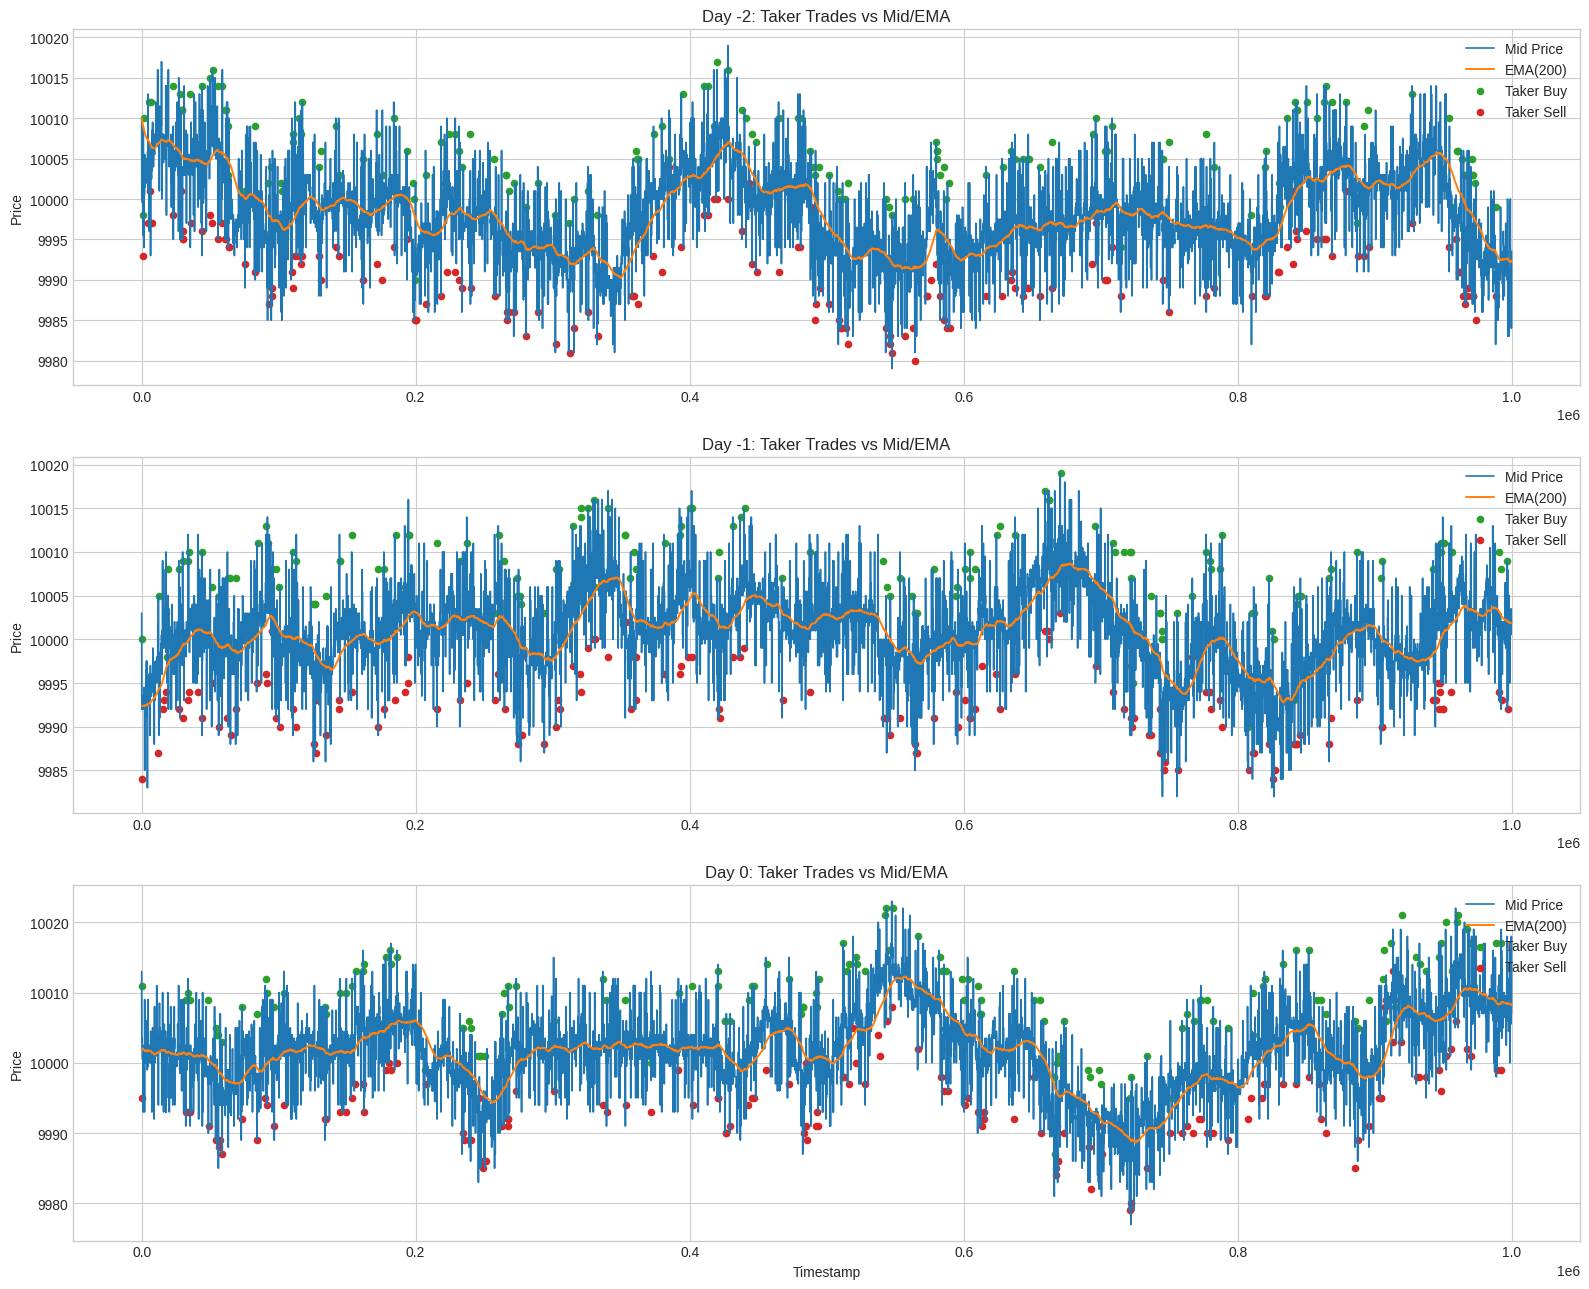

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)

for ax, day in zip(axes, sorted(ash['day'].unique())):
    day_quotes = ash.loc[ash['day'] == day]
    day_trades = trades.loc[trades['day'] == day]
    x = day_quotes['timestamp']

    ax.plot(x, day_quotes['mid_price'], color='tab:blue', linewidth=1.2, label='Mid Price')
    ax.plot(x, day_quotes['ema'], color='tab:orange', linewidth=1.4, label=f'EMA({EMA_SPAN})')

    buy_trades = day_trades.loc[day_trades['side'] == 'BUY']
    sell_trades = day_trades.loc[day_trades['side'] == 'SELL']

    ax.scatter(buy_trades['timestamp'], buy_trades['price'], color='tab:green', s=20, label='Taker Buy')
    ax.scatter(sell_trades['timestamp'], sell_trades['price'], color='tab:red', s=20, label='Taker Sell')

    ax.set_title(f'Day {day}: Taker Trades vs Mid/EMA')
    ax.set_ylabel('Price')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.show()


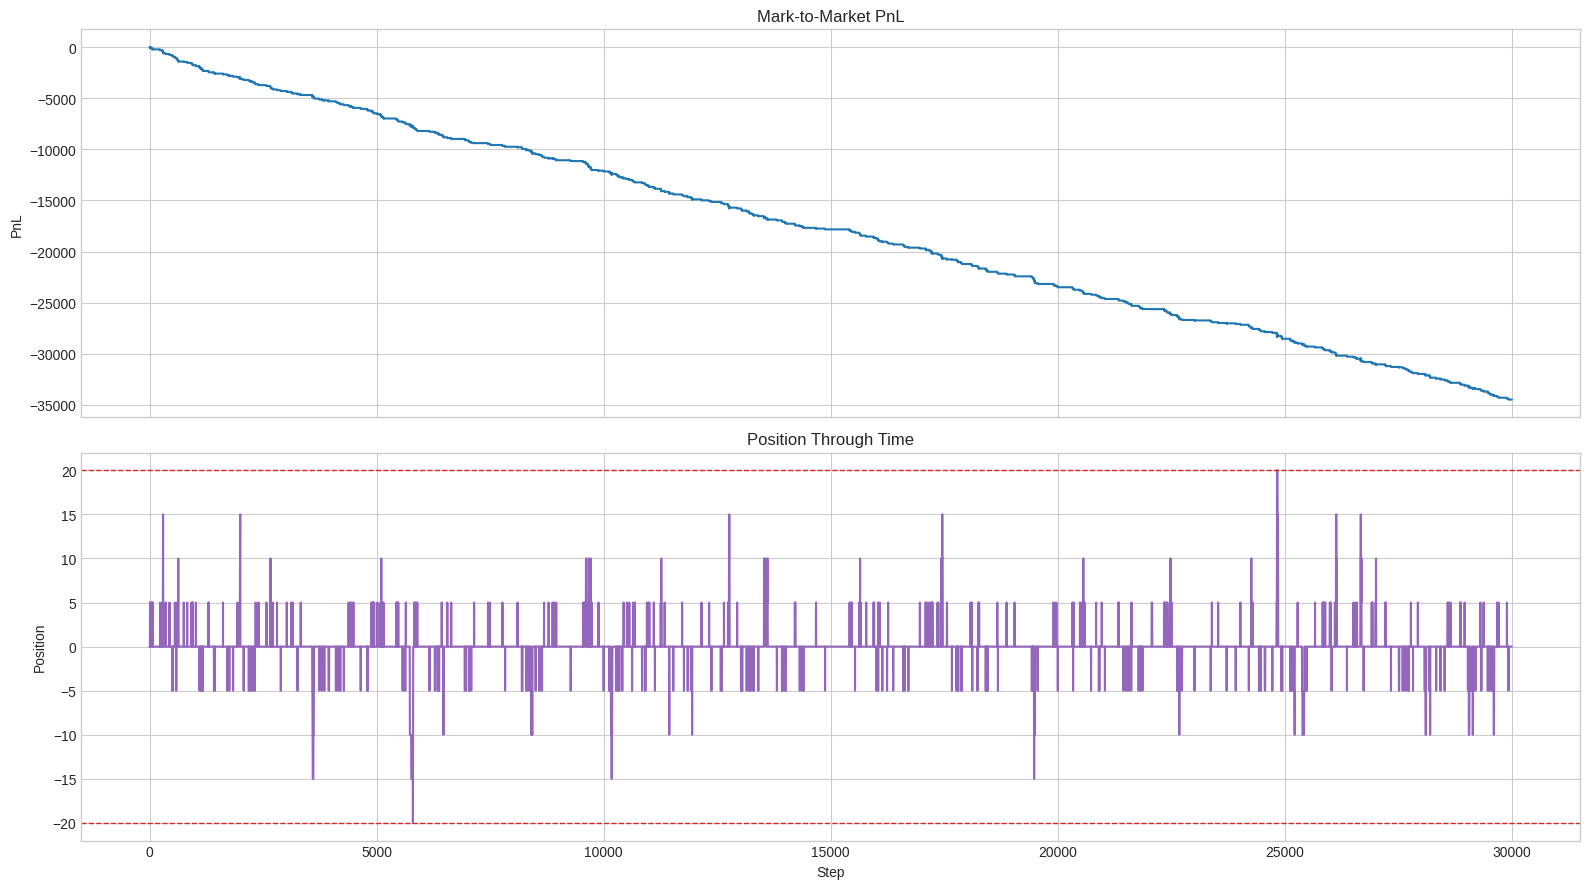

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(history['global_step'] if 'global_step' in history else np.arange(len(history)), history['mtm_pnl'], color='tab:blue')
axes[0].set_title('Mark-to-Market PnL')
axes[0].set_ylabel('PnL')

axes[1].plot(history['global_step'] if 'global_step' in history else np.arange(len(history)), history['position'], color='tab:purple')
axes[1].axhline(POSITION_LIMIT, color='tab:red', linestyle='--', linewidth=1.0)
axes[1].axhline(-POSITION_LIMIT, color='tab:red', linestyle='--', linewidth=1.0)
axes[1].set_title('Position Through Time')
axes[1].set_ylabel('Position')
axes[1].set_xlabel('Step')

plt.tight_layout()
plt.show()


In [16]:
daily_pnl = history.groupby('day', observed=False).agg(final_pnl=('mtm_pnl', 'last')).reset_index()
daily_pnl['day_pnl_change'] = daily_pnl['final_pnl'].diff()
daily_pnl.loc[daily_pnl.index[0], 'day_pnl_change'] = daily_pnl.loc[daily_pnl.index[0], 'final_pnl']
daily_pnl


,day,final_pnl,day_pnl_change
0,-2,"-12,080.000","-12,080.000"
1,-1,"-23,405.000","-11,325.000"
2,0,"-34,470.000","-11,065.000"
